In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
housing = fetch_california_housing()

In [3]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

In [4]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [5]:
print(df.shape)

(20640, 9)


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
X = df.drop('target', axis=1)
y = df['target']

In [9]:
print(X)
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [16]:
print("Model Evaluation Metrics")
print("---------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Model Evaluation Metrics
---------------------------
Mean Absolute Error (MAE): 0.5315993265472098
Mean Squared Error (MSE): 0.5607698205570408
Root Mean Squared Error (RMSE): 0.7488456587021393
R-squared (R2): 0.5801023059696645


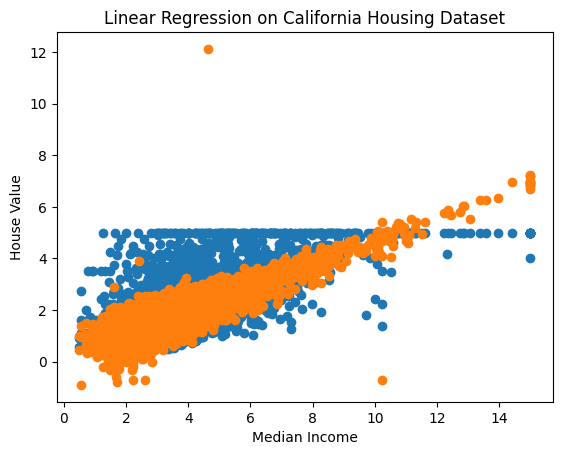

In [17]:
plt.scatter(X_test['MedInc'], y_test)
plt.scatter(X_test['MedInc'], y_pred)
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.title('Linear Regression on California Housing Dataset')
plt.show()

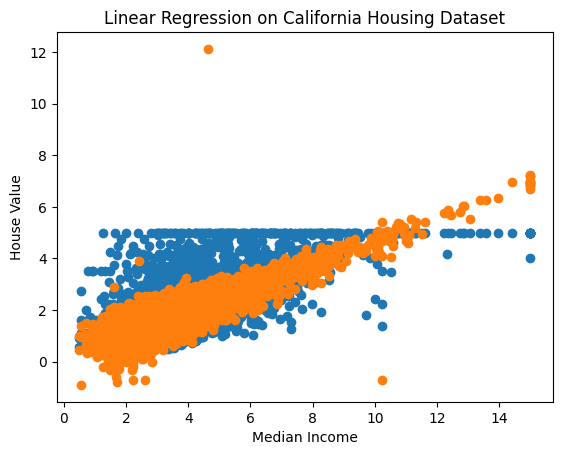

In [18]:
plt.scatter(X_test['MedInc'], y_test)
plt.scatter(X_test['MedInc'], y_pred)
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.title('Linear Regression on California Housing Dataset')
plt.show()

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [20]:
print("Model Evaluation Metrics")
print("---------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


Model Evaluation Metrics
---------------------------
Mean Absolute Error (MAE): 0.5315993265472098
Mean Squared Error (MSE): 0.5607698205570408
Root Mean Squared Error (RMSE): 0.7488456587021393
R-squared (R2): 0.5801023059696645


In [21]:
comparison = pd.DataFrame({
    'Actual Values': y_test,
    'Predicted Values': y_pred
})

print(comparison.head(10))

       Actual Values  Predicted Values
18800        0.65600          0.366287
2035         0.50000          1.032415
19224        2.40500          2.341213
1569         3.99300          3.535757
14478        2.77500          2.678121
5518         3.61400          3.323706
10458        5.00001          5.511759
19425        1.37700          1.484508
6088         1.80600          1.752636
3152         0.94900          1.152406


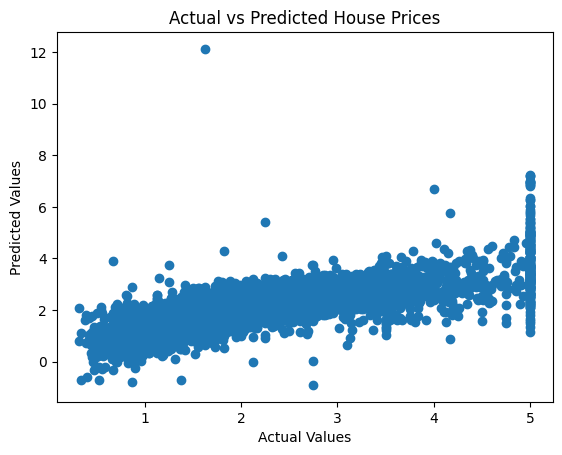

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()

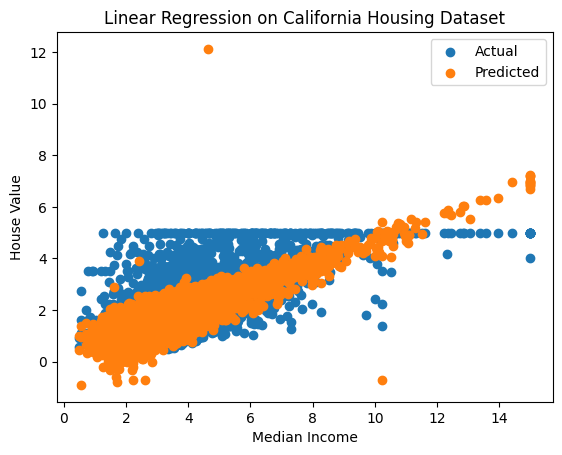

In [23]:
plt.scatter(X_test['MedInc'], y_test, label="Actual")
plt.scatter(X_test['MedInc'], y_pred, label="Predicted")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression on California Housing Dataset")
plt.legend()
plt.show()

In [24]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

             Coefficient
MedInc      4.449296e-01
HouseAge    9.757141e-03
AveRooms   -1.186552e-01
AveBedrms   7.845127e-01
Population  8.345086e-07
AveOccup   -4.640385e-03
Latitude   -4.238754e-01
Longitude  -4.382434e-01


In [25]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Sample Input:\n", sample)
print("Predicted House Value:", prediction)

Sample Input:
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
18800   2.503      17.0  6.935961   1.573892      1027.0  2.529557     40.77   

       Longitude  
18800    -121.86  
Predicted House Value: [0.36628727]
